# NMHS Exercise 1 - Wave Equation

 The one-dimensional wave equation is a second-order linear partial differential equation (PDE)  that describes the propagation of waves, such as sound waves, light waves, or water waves, in  a given medium. The equation is given by:  

 $\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$ 

In the following code is shown (and explain) how to solve it numerically by the means of the second order central difference shceme for space and time derivatives, starting from the initial conditions from the problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

In [6]:
func = lambda x: np.sin(10 * np.pi * x)

M = 140 # Last three digits of the Matriculation Number
c = 0.2 + (0.4 * M /1000) # Speed of wave in medium

# Time steps required
t1 = np.round(0.1 * (4.2 - (0.7 * M /1000)),4)
t2 = np.round(0.2 * (4.2 - (0.7 * M /1000)),4)
t3 = np.round(0.5 * (4.2 - (0.7 * M /1000)),4)
t4 = np.round(0.9 * (4.2 - (0.7 * M /1000)),4)
t5 = np.round((4.2 - (0.7 * M /1000)),4)

from dataclasses import dataclass
from enum import Enum

class BoundaryCondition(Enum):
    DIRICHLET = "dirichlet"
    NEUMANN = "neumann"
    PERIODIC = "periodic"

# Dataclass added in order to separate parameters from the function, 
# so it will be easier to call when different boundary conditions are used
@dataclass
class SolutionType:
    dx: float
    dt: float
    boundary_condition: BoundaryCondition

In [3]:
# Time and space discretization

dx = 0.001# Discretization in space
dt = t1 / 1000 # Discretization on time

CFL = c * dt / dx
print("CFL = ", CFL, "< 1 for stability condition")

CFL =  0.1050112 < 1 for stability condition


In [ ]:


def numerical_solution(solution: SolutionType, animation_name: str = "anim") -> None:

  dx = solution.dx
  dt = solution.dt
  boundary_condition = solution.boundary_condition

  # Space Grid
  X = np.arange(0, 1 + dx, dx)

  # Time array
  T = np.arange(0, 1.5 * t5, dt) # Time array, includes t1, t2, t3, t4, t5 in its steps for main simulations
  if dt == t1 / 1000:
    print(f"t1: {t1} or {T[100]}, t2: {t2}or {T[200]}, t3: {t3} or {T[500]}, t4: {t4} or {T[900]}, t5: {t5} or {T[1000]}")

  # Check stability condition
  CFL = c * dt / dx
  print("CFL = ", CFL, "< 1 for stability condition")

  if CFL >= 1:
     print("Stability condition not met. Inestable solution.")

  # Initial Conditions
  
  # U at time 0
  u0 = np.zeros_like(X)
  u0[(X > 0.1) & (X <= 0.2)] = func(X[(X > 0.1) & (X <= 0.2)])

  # U at time dt
  u1 = np.zeros_like(X)
  u1[(X > 0.1 + c * dt) & (X <= 0.2 + c * dt)] = func(X[(X > 0.1 + c * dt) & (X <= 0.2 + c * dt)] - c * dt)

  # Snapshots for animated visualization
  snapshots = []

  # Plotting initial condition
  plt.figure(figsize = (12, 8))
  plt.plot(X, u0, label = 't = 0')

  # Stablishing the first two time steps
  u_back = u0
  u_central = u1

  for w in range(len(T)):

    u_new = np.zeros_like(X)

    for i in range(1, len(X) - 1):
      u_new[i] = c**2 * (dt**2 / dx**2) * (u_central[i+1] - 2 * u_central[i] + u_central[i-1]) + 2 * u_central[i] - u_back[i]

    # Applying Boundary Conditions
    if boundary_condition == BoundaryCondition.DIRICHLET:
      u_new[0] = 0
      u_new[-1] = 0
    elif boundary_condition == BoundaryCondition.NEUMANN:
      u_new[0] = u_new[1]
      u_new[-1] = u_new[-2]
    elif boundary_condition == BoundaryCondition.PERIODIC:
      u_new[0] = u_new[-2]
      u_new[-1] = u_new[1]

    if np.round(T[w], 4) in (t1, t2, t3, t4, t5):
      plt.plot(X, u_new, label = f't = {T[w]:.4f}')

    if w % 100 == 0:
        snapshots.append(u_new.copy())

    u_back = u_central
    u_central = u_new

  import matplotlib.animation as animation

  # Part of code added to show the animation inline in Jupyter Notebooks
  %matplotlib inline
  from matplotlib import rc
  rc('animation', html='jshtml')


   # Figure aesthetics
  fig, ax = plt.subplots(figsize=(10, 6))  # más grande
  line, = ax.plot(X, snapshots[0], lw=2, color="C0")

  ymin = min(min(s) for s in snapshots)
  ymax = max(max(s) for s in snapshots)
  print(ymin, ymax)

  ax.set_xlim(X[0], X[-1])
  ax.set_ylim(ymin * 1.1, ymax * 1.1)

  ax.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.7)

  ax.set_xlabel("x", fontsize=12)
  ax.set_ylabel("u(x, t)", fontsize=12)
  ax.set_title("Timestep 0", fontsize=14)

  # Animation update function
  def update(frame):
      line.set_ydata(snapshots[frame])
      ax.set_title(f"Timestep {frame}", fontsize=14)
      return [line]

  global ani

  ani = animation.FuncAnimation(
      fig,
      update,
      frames=len(snapshots),
      interval=120,  # un poco más suave
      blit=True
  )

  # Save video file
  ani.save(f"{animation_name}.mp4", writer="ffmpeg", fps=10, dpi=100)

  plt.legend(["u(x,t)"], fontsize=10)
  plt.show()



## 0.1 Solution with Dirichlet Boundary Conditions and a non-optimal dx

The solution is still stable (no instabilities appear), but using a larger spatial step makes the curves noticeably rougher and increases numerical noise.
Regarding the question of when the discretization becomes “too large”, it really depends on how smooth the solution needs to be.
In this case, with dx = 0.01, the noise is high enough that the result shouldn’t be considered acceptable.

t1: 0.4102 or 0.04102, t2: 0.8204or 0.08204, t3: 2.051 or 0.2051, t4: 3.6918 or 0.36918, t5: 4.102 or 0.4102
CFL =  0.01050112 < 1 for stability condition
-1.1434338711736383 1.114412101683795


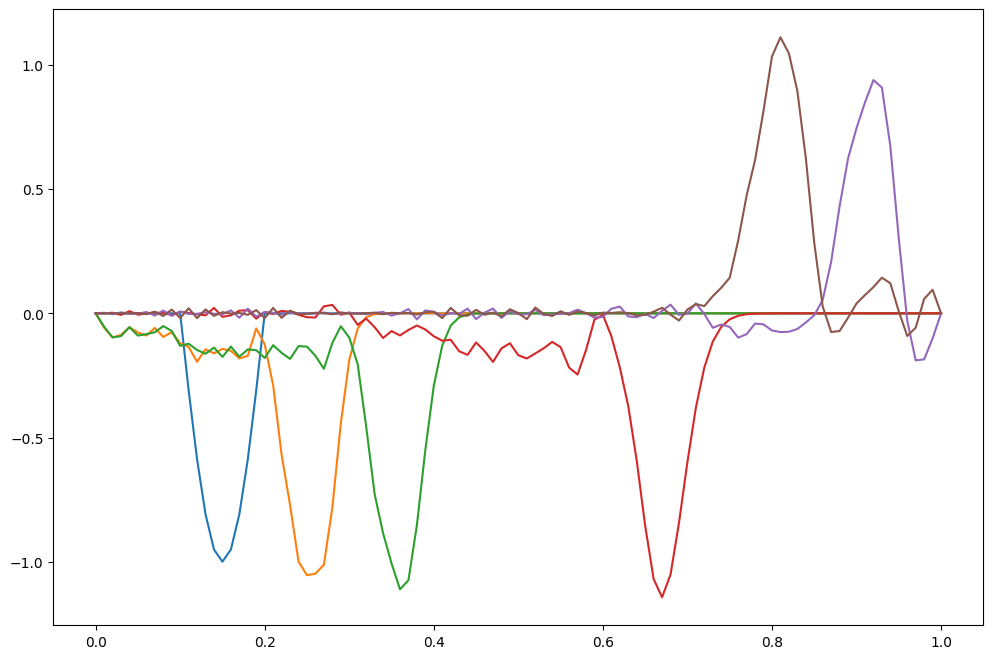

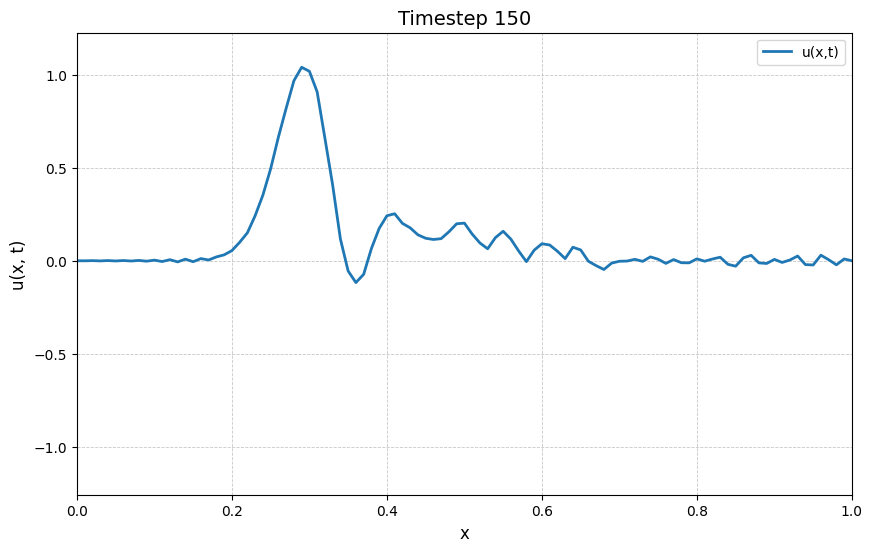

In [5]:


solution_01 = SolutionType(
    dx = 0.01,
    dt = dt,
    boundary_condition = BoundaryCondition.DIRICHLET
)


numerical_solution(solution_01, animation_name="anim_dirichlet_dx_changed")

## 0.2 Solution with Dirichlet Boundary Conditions and a non-optimal dt

In this case, dt is smaller than necessary, so the solution still looks very similar to the “correct” one.
This happens because instabilities only appear when dt becomes too large—specifically when the CFL number exceeds 1, so for this 0.8 still looks "good", since if dt is increased significantly (for example, using dt × 50), the solution quickly blows up and goes to infinity.

On the other hand, reducing dt even more can produce a slightly smoother result, but the improvement is small compared to the extra computational cost, so it’s usually not worth it.

CFL =  0.8400896 < 1 for stability condition
-1.002948274902208 1.0038435740896066


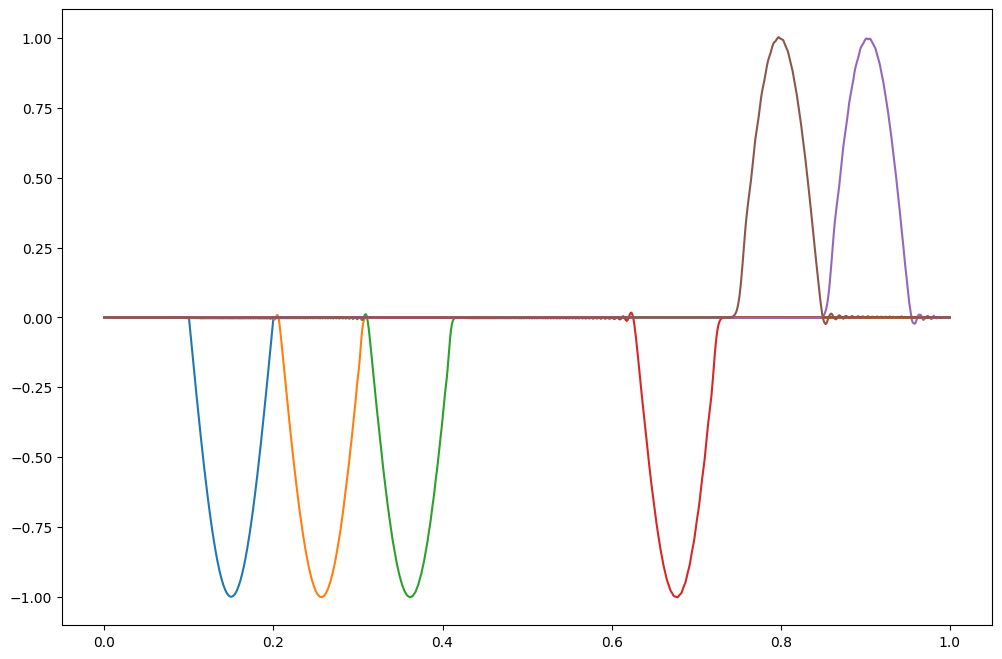

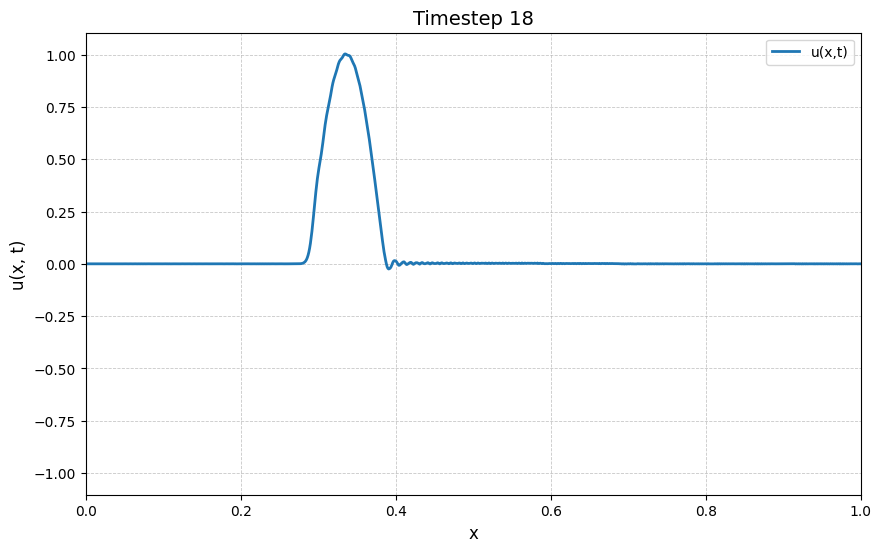

In [6]:
solution_02 = SolutionType(
    dx = dx,
    dt = dt * 8,
    boundary_condition = BoundaryCondition.DIRICHLET
)


numerical_solution(solution_02, animation_name="anim_dirichlet_dt_changed")

## 1. Solution with Dirichlet Boundary Conditions

For this first solution the Dirichlet boundary conditions were used, with the discretization values:

$dx = 0.001$

$dt = t1 / 1000$

These values were chosen simply to keep the solution stable (CFL condition), reduce numerical noise (by having a smaller dx than with the first tries), and make sure that dt multiply by some values correspond with the t1, t2, etc, so they are easy to plot.

In the graph is possible to see how the wave travels through the domain, reaches the boundary, and then reflects. The initial conditions set the direction and the sign of the wave at the beginning, and the Dirichlet boundaries are what cause the reflection and the sign flip when the wave hits the ends.

To make the computation work correctly, the update step only computes u_new from index 1 to –2.
The extreme points (index 0 and –1) are not updated inside the loop; they are assigned after the new values have been computed.
This ensures that the boundaries are imposed at the end of each time step—in this case, setting:

u_new[0] = 0

u_new[-1] = 0

t1: 0.4102 or 0.04102, t2: 0.8204or 0.08204, t3: 2.051 or 0.2051, t4: 3.6918 or 0.36918, t5: 4.102 or 0.4102
CFL =  0.1050112 < 1 for stability condition
-1.0106682420945239 1.0139183940429866


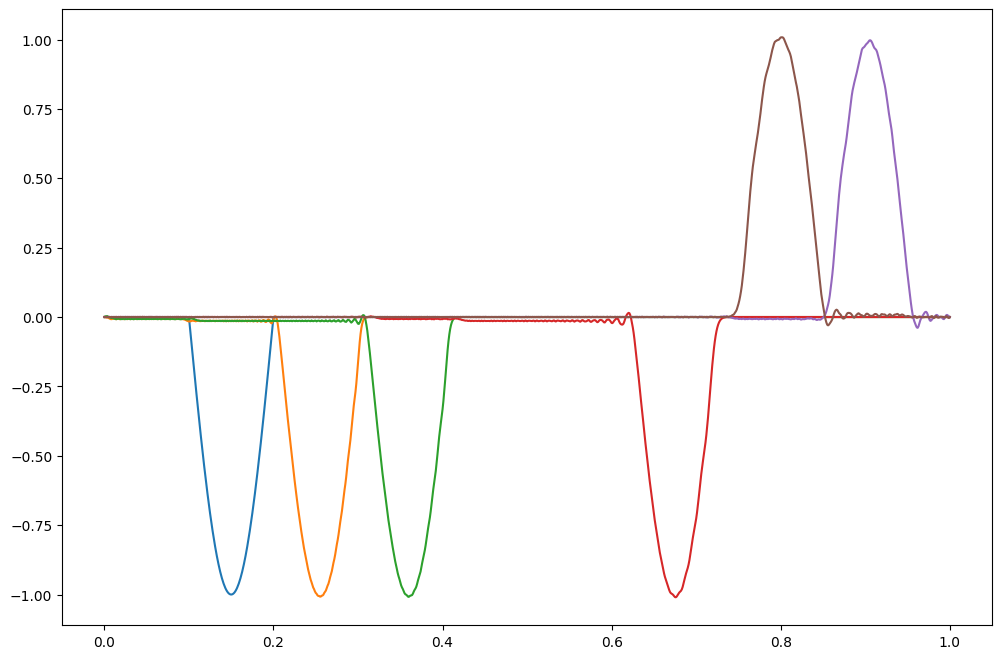

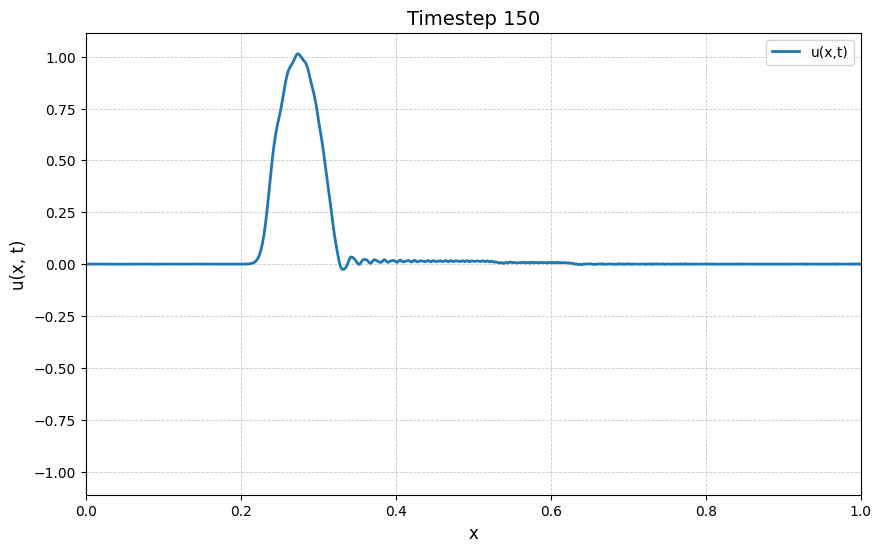

In [7]:
solution_1 = SolutionType(
    dx = dx,
    dt = dt,
    boundary_condition = BoundaryCondition.DIRICHLET
)


numerical_solution(solution_1, animation_name="anim_dirichlet")

## 2. Solution with Neumann Boundary Conditions

For this case, the same code from the Dirichlet solution is used, with one change in the boundary treatment.
Instead of forcing the ends of the domain to be zero, the values at the boundaries are assigned from their adjacent nodes:

u_new[0] = u_new[1]

u_new[-1] = u_new[-2]

This imposes a zero-gradient condition $(\partial u/\partial x = 0)$ at both ends.

With this setup, the wave propagates as before, but it keeps the same sign when it reaches the boundary.
This happens because Neumann conditions do not force the wave to cross zero or change sign.
They simply ensure the slope is zero at the boundary, meaning the wave reaches the edge with a flat profile.
As a result, the reflection does not invert the wave; the sign is preserved.

t1: 0.4102 or 0.04102, t2: 0.8204or 0.08204, t3: 2.051 or 0.2051, t4: 3.6918 or 0.36918, t5: 4.102 or 0.4102
CFL =  0.1050112 < 1 for stability condition
-2.014641122924969 0.020403598653339038


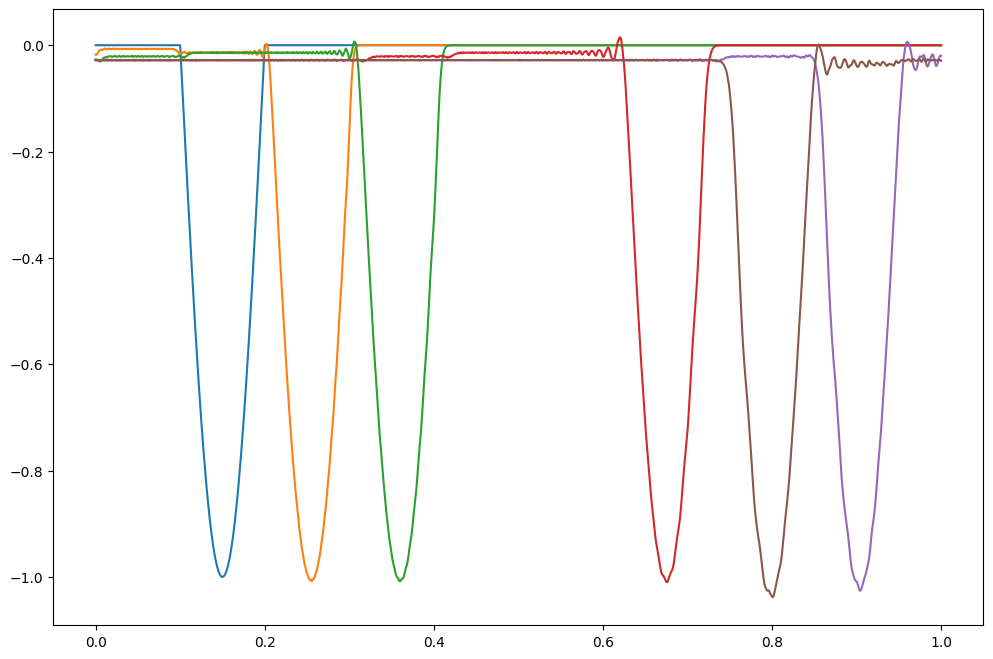

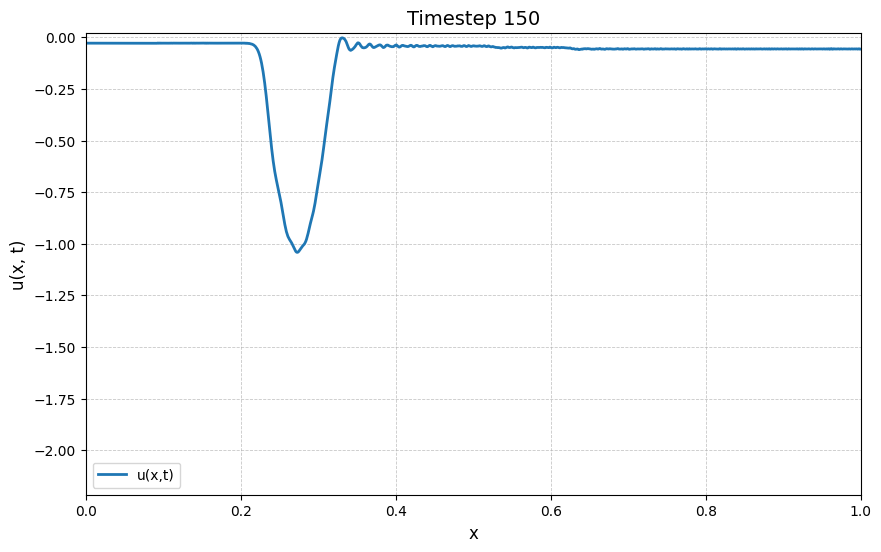

In [8]:
solution_2 = SolutionType(
    dx = dx,
    dt = dt,
    boundary_condition = BoundaryCondition.NEUMANN
)


numerical_solution(solution_2, animation_name="anim_neumann")

## 3. Solution with Periodic Boundary Conditions

In this case, the boundary treatment is modified so that the values at the ends of the domain connect seamlessly.
The boundary update is:

u_new[0] = u_new[-2]

u_new[-1] = u_new[1]

This is done because, under periodicity, the points at indices 0 and -1 represent the same physical location on the domain. They act as ghost cells that connect to their “neighbors” across the boundary:

-2   |   -1 = 0   |   1


left | boundary   | right


This enforces periodic boundary conditions, meaning the left and right edges behave as if the domain were “wrapped around” into a loop.

With this setup, the wave does not reflect at the boundaries.
Instead, when it reaches one end of the domain, it reappears at the opposite end and continues propagating with the same shape and sign.
This behavior occurs because periodic boundaries do not introduce reflections at all—they maintain continuity and effectively create a circular domain.

t1: 0.4102 or 0.04102, t2: 0.8204or 0.08204, t3: 2.051 or 0.2051, t4: 3.6918 or 0.36918, t5: 4.102 or 0.4102
CFL =  0.1050112 < 1 for stability condition
-1.0557560743163825 0.01529186730728007


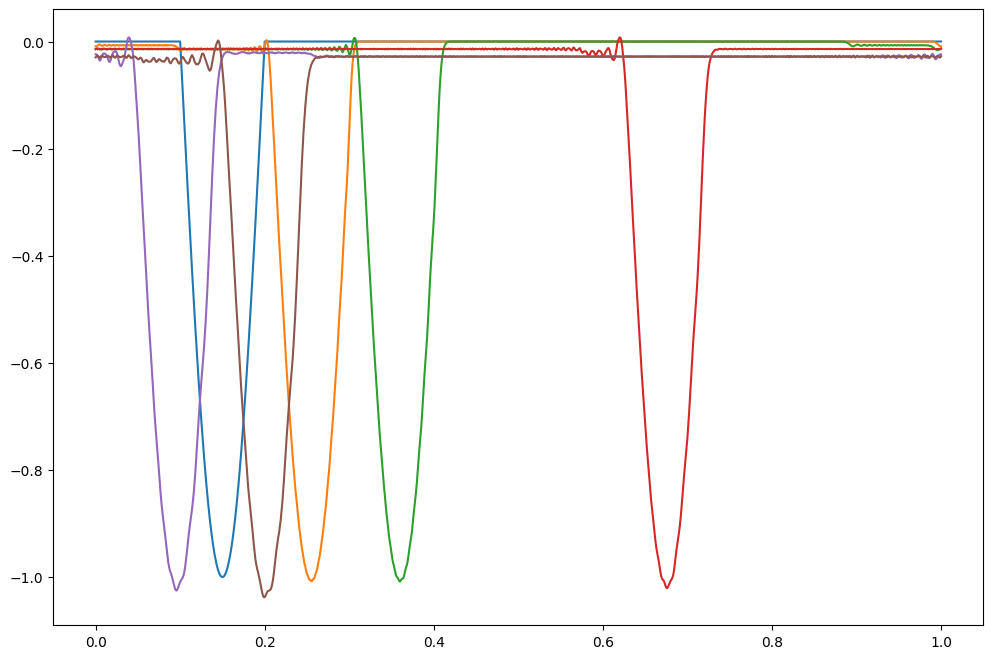

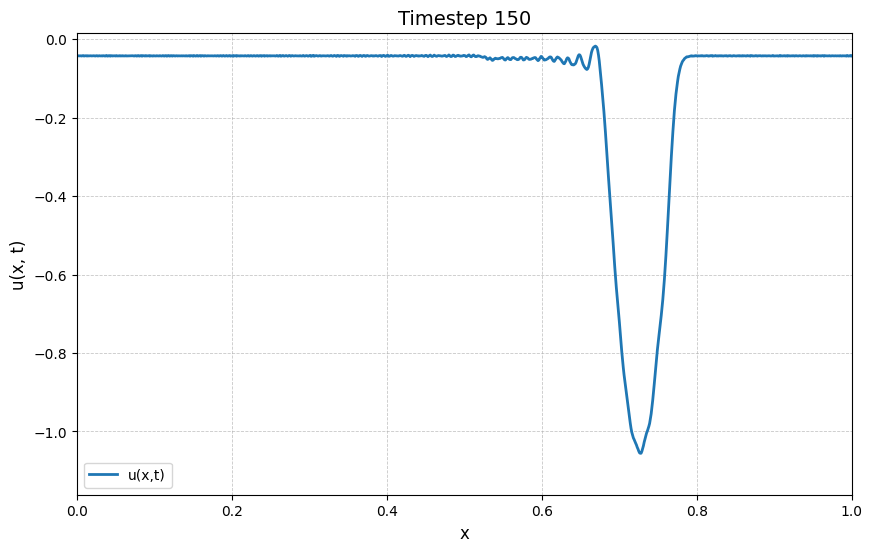

In [9]:
solution_3 = SolutionType(
    dx = dx,
    dt = dt,
    boundary_condition = BoundaryCondition.PERIODIC
)


numerical_solution(solution_3, animation_name="anim_periodic")

t1: 0.4102 or 0.04102, t2: 0.8204or 0.08204, t3: 2.051 or 0.2051, t4: 3.6918 or 0.36918, t5: 4.102 or 0.4102
CFL =  0.1050112 < 1 for stability condition
-1.005890546040499 0.9546310540020042


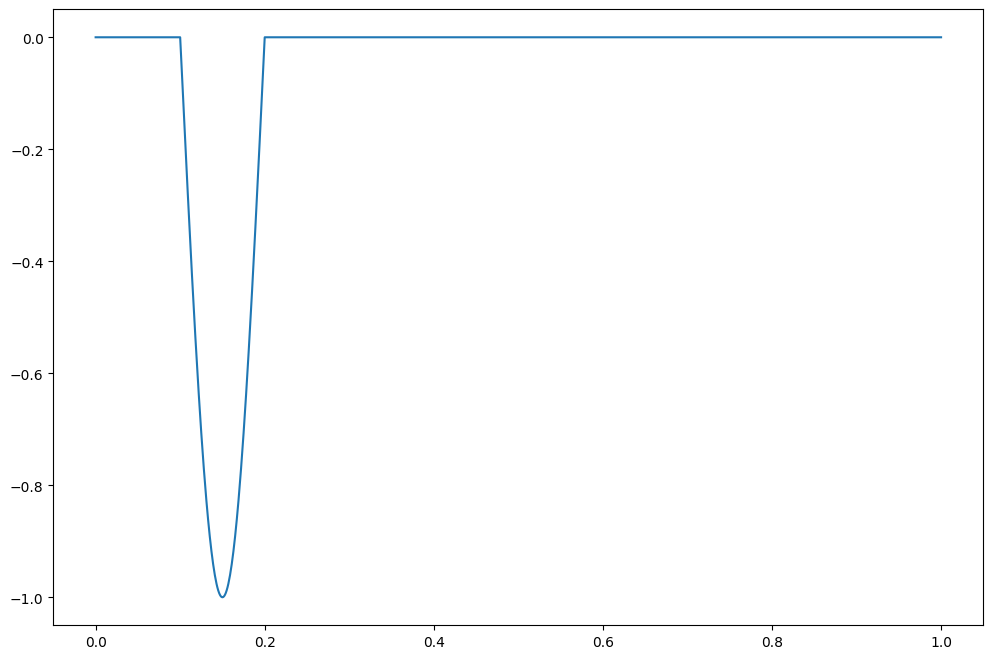

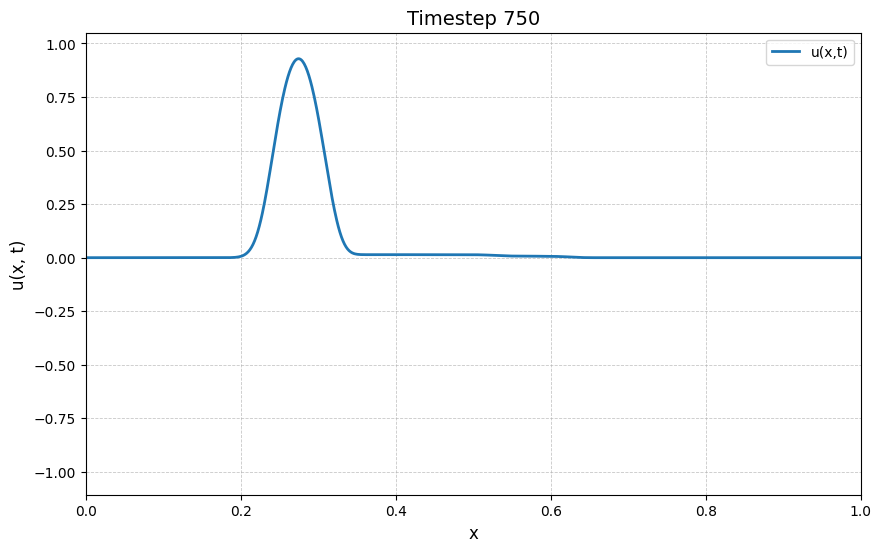

In [9]:

# Dataclass added in order to separate parameters from the function, 
# so it will be easier to call when different boundary conditions are used


def animation_from_array(X: np.ndarray, Y: np.ndarray, animation_name: str) -> None:
    import matplotlib.animation as animation

    # Part of code added to show the animation inline in Jupyter Notebooks
    from matplotlib import rc
    rc('animation', html='jshtml')


    # Figure aesthetics
    fig, ax = plt.subplots(figsize=(10, 6))  # más grande
    line, = ax.plot(X, Y[0], lw=2, color="C0")

    ymin = np.min(Y)
    ymax = np.max(Y)
    
    print(ymin, ymax)

    ax.set_xlim(X[0], X[-1])
    ax.set_ylim(ymin * 1.1, ymax * 1.1)

    ax.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.7)

    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("u(x, t)", fontsize=12)
    ax.set_title("Timestep 0", fontsize=14)

    # Animation update function
    def update(frame):
        line.set_ydata(Y[frame])
        ax.set_title(f"Timestep {frame}", fontsize=14)
        return [line]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(Y),
        interval=120,  # un poco más suave
        blit=True
    )

      # Save video file
    ani.save(f"{animation_name}.mp4", writer="ffmpeg", fps=10, dpi=100)

    plt.legend(["u(x,t)"], fontsize=10)
    plt.show()

@dataclass
class SolutionType:
    dx: float
    dt: float
    boundary_condition: BoundaryCondition

def implicit_numerical_solution(solution: SolutionType, animation_name: str = "anim") -> None:

  dx = solution.dx
  dt = solution.dt
  boundary_condition = solution.boundary_condition

  LAMBDA = (c * dt / dx)**2

  # Space Grid
  X = np.arange(0, 1 + dx, dx)

  # Time array
  T = np.arange(0, 1.5 * t5, dt) # Time array, includes t1, t2, t3, t4, t5 in its steps for main simulations
  if dt == t1 / 1000:
    print(f"t1: {t1} or {T[100]}, t2: {t2}or {T[200]}, t3: {t3} or {T[500]}, t4: {t4} or {T[900]}, t5: {t5} or {T[1000]}")

  # Check stability condition
  CFL = c * dt / dx
  print("CFL = ", CFL, "< 1 for stability condition")

  if CFL >= 1:
     print("Stability condition not met. Inestable solution.")

  # Initial Conditions
  
  # U at time 0
  u0 = np.zeros_like(X)
  u0[(X > 0.1) & (X <= 0.2)] = func(X[(X > 0.1) & (X <= 0.2)])

  # U at time dt
  u1 = np.zeros_like(X)
  u1[(X > 0.1 + c * dt) & (X <= 0.2 + c * dt)] = func(X[(X > 0.1 + c * dt) & (X <= 0.2 + c * dt)] - c * dt)

  # Snapshots for animated visualization
  snapshots = []

  # Plotting initial condition
  plt.figure(figsize = (12, 8))
  plt.plot(X, u0, label = 't = 0')

  # Stablishing the first two time steps
  u_back = u0
  u_central = u1

  N = len(X) # Matriz size
  u_new = np.zeros_like(X)

  diag = (1 + 2 * LAMBDA) * np.ones(N)
  upper = -LAMBDA * np.ones(N - 1)
  lower = -LAMBDA * np.ones(N - 1)

  diagonal_matrix = [lower, diag, upper]

  A = diags(diagonal_matrix, [-1, 0, 1], format='csr') # type: ignore
  A = A.tolil()
  if boundary_condition == BoundaryCondition.DIRICHLET:
    
    # First row
    A[0, :] = 0
    A[0, 0] = 1

    # Last row
    A[-1, :] = 0
    A[-1, -1] = 1

    # Convert back to CSR
    A = A.tocsr()

  elif boundary_condition == BoundaryCondition.NEUMANN:
    # First row
    A[0, :] = 0
    A[0, 0] = -1
    A[0, 1] = 1

    # Last row
    A[-1, :] = 0
    A[-1, -1] = -1
    A[-1, -2] = 1

    # Convert back to CSR
    A = A.tocsr()

  elif boundary_condition == BoundaryCondition.PERIODIC:
    # First row
    A[0, :] = 0
    A[0, 0] = 1 + 2 * LAMBDA
    A[0, 1] = -LAMBDA
    A[0, -2] = -LAMBDA

    # Last row
    A[-1, :] = 0
    A[-1, -1] = 1 + 2 * LAMBDA
    A[-1, -2] = -LAMBDA
    A[-1, 1] = -LAMBDA

    # Convert back to CSR
    A = A.tocsr()

  for w in range(len(T)):

    b = (2 * u_central - u_back).copy()
    # Applying Boundary Conditions
    if boundary_condition == BoundaryCondition.DIRICHLET:
      b[0] = 0
      b[-1] = 0

    elif boundary_condition == BoundaryCondition.NEUMANN:
      b[0] = 0
      b[-1] = 0


    u_new = spsolve(A, b)


    if w % 20 == 0:
      snapshots.append(u_new.copy())

    u_back = u_central
    u_central = u_new

  animation_from_array(X, np.array(snapshots), animation_name)

toy_solution = SolutionType(
    dx = dx,
    dt = dt,
    boundary_condition = BoundaryCondition.DIRICHLET
)



implicit_numerical_solution(toy_solution)

## Student: Juan David Guerrero Delgado

## Matriculation Number: 5329140